# Linear Eigenvalue Analysis for Euler Equations

## Dispersion data processing

In [22]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.colors import ListedColormap
from matplotlib.cm import get_cmap
import pandas as pd

def parse_eigenvalue_file(filename):
    """
    Parse eigenvalue files from MLegS Euler output.
    
    Parameters:
    -----------
    filename : str
        Path to the eigenvalue file
        
    Returns:
    --------
    dict
        Dictionary containing the parsed data
    """
    # Extract parameters from filename for Euler case (no bv/w parameters)
    pattern = r"eig_m_(\d+)_k_([+-]?[0-9.]+)_nr_([+-]?\d+)"
    match = re.search(pattern, filename)
    
    if match:
        m = int(match.group(1))
        k = float(match.group(2))
        nrchop = int(match.group(3))
    else:
        print(f"Couldn't parse parameters from {filename}")
        return None
    
    # Parse file content
    eigenvalues = []
    is_resolved = []
    indices = []
    
    with open(filename, 'r') as file:
        for line in file:
            # Match the eigenvalue format
            match = re.search(r'II\s*=\s*(\d+)\s*:\s*\(([^,]+),([^)]+)\)\s*-\s*([TF])', line)
            if match:
                index = int(match.group(1))
                real_part = float(match.group(2))
                imag_part = float(match.group(3))
                resolved = match.group(4) == 'T'
                
                indices.append(index)
                eigenvalues.append(complex(real_part, imag_part))
                is_resolved.append(resolved)
    
    return {
        'm': m,
        'k': k,
        'nrchop': nrchop,
        'indices': np.array(indices),
        'eigenvalues': np.array(eigenvalues),
        'is_resolved': np.array(is_resolved)
    }

def read_velocity_profile(data_dir, m, k, index):
    """
    Read velocity profile data for a specific eigenvalue index (Euler case).
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
    index : int
        Eigenvalue index
        
    Returns:
    --------
    dict
        Dictionary with radial coordinates, velocity components, 
        and metadata (no buoyancy field for Euler equations)
    """
    # Format the filename based on parameters (Euler case)
    k_str = f"{k:.3f}"
    
    vel_dir = f"{data_dir}/vel_m_{m}_k_{k_str}"
    vel_file = f"{vel_dir}/ind_{index}.output"
    
    try:
        # Try to read the velocity file
        data = []
        with open(vel_file, 'r') as file:
            for line in file:
                # Parse comma-separated values
                values = [float(val) for val in line.strip().split(',')]
                data.append(values)
        
        # Convert to numpy array
        data = np.array(data)
        
        # Create a structured output (only 3 velocity components for Euler)
        velocity_data = {
            'r': data[:, 0],
            'ur_real': data[:, 1],
            'ur_imag': data[:, 2],
            'uphi_real': data[:, 3],
            'uphi_imag': data[:, 4],
            'uz_real': data[:, 5],
            'uz_imag': data[:, 6],
            'ur': data[:, 1] + 1j * data[:, 2],
            'uphi': data[:, 3] + 1j * data[:, 4],
            'uz': data[:, 5] + 1j * data[:, 6],
            'metadata': {
                'm': m,
                'k': k,
                'index': index
            }
        }
        
        return velocity_data
    
    except (FileNotFoundError, IOError) as e:
        print(f"Error reading velocity file {vel_file}: {e}")
        return None

# Function to plot velocity profiles for a specific eigenvalue
def plot_velocity_profiles(data_dir, m, k, index, r_min=0, r_max=5):
    """
    Plot velocity profiles for a specific eigenvalue index (Euler case).
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
    index : int
        Eigenvalue index
    """
    vel_data = read_velocity_profile(data_dir, m, k, index)
    
    if vel_data is None:
        print("No velocity data available.")
        return
    
    # Create a figure with 3 subplots for ur, uphi, and uz
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Get the radial coordinate
    r = vel_data['r']
    
    # Calculate magnitudes
    ur_mag = np.abs(vel_data['ur'])
    uphi_mag = np.abs(vel_data['uphi'])
    uz_mag = np.abs(vel_data['uz'])
    
    # Plot radial velocity
    ax1.plot(r, vel_data['ur_real'], 'b-', label='Real')
    ax1.plot(r, vel_data['ur_imag'], 'r-', label='Imaginary')
    ax1.plot(r, ur_mag, 'k--', label='Magnitude')
    ax1.set_xlabel('r')
    ax1.set_ylabel('ur')
    ax1.set_title('Radial Velocity')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(r_min, r_max)
    
    # Plot azimuthal velocity
    ax2.plot(r, vel_data['uphi_real'], 'b-', label='Real')
    ax2.plot(r, vel_data['uphi_imag'], 'r-', label='Imaginary')
    ax2.plot(r, uphi_mag, 'k--', label='Magnitude')
    ax2.set_xlabel('r')
    ax2.set_ylabel('uφ')
    ax2.set_title('Azimuthal Velocity')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(r_min, r_max)
    
    # Plot axial velocity
    ax3.plot(r, vel_data['uz_real'], 'b-', label='Real')
    ax3.plot(r, vel_data['uz_imag'], 'r-', label='Imaginary')
    ax3.plot(r, uz_mag, 'k--', label='Magnitude')
    ax3.set_xlabel('r')
    ax3.set_ylabel('uz')
    ax3.set_title('Axial Velocity')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    ax3.set_xlim(r_min, r_max)
    
    plt.tight_layout()
    plt.show()

    return vel_data

# Example usage:
# velocity_data = read_velocity_profile("/Users/jinge/Projects/MLegS-dev/MLegS/data", 2, 1.0, 1)
# plot_velocity_profiles("/Users/jinge/Projects/MLegS-dev/MLegS/data", 2, 1.0, 1)

In [23]:
def read_baseflow(data_dir):
    """
    Read the baseflow profile from base.output file.
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
        
    Returns:
    --------
    dict
        Dictionary with radial coordinates and baseflow velocity components
    """
    base_file = f"{data_dir}/base.output"
    
    try:
        # Read the baseflow file
        data = []
        with open(base_file, 'r') as file:
            for line in file:
                # Parse space-separated values
                values = [float(val) for val in line.strip().split()]
                data.append(values)
        
        # Convert to numpy array
        data = np.array(data)
        
        # Create a structured output
        baseflow_data = {
            'r': data[:, 0],
            'ur': data[:, 1],
            'uphi': data[:, 2],
            'uz': data[:, 3]
        }
        
        return baseflow_data
    
    except (FileNotFoundError, IOError) as e:
        print(f"Error reading baseflow file {base_file}: {e}")
        return None

def plot_baseflow(data_dir, r_min=0, r_max=5):
    """
    Plot the baseflow velocity profiles.
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    r_min, r_max : float
        Radial range for plotting
    """
    base_data = read_baseflow(data_dir)
    
    if base_data is None:
        print("No baseflow data available.")
        return
    
    # Create a figure with 3 subplots for ur, uphi, and uz
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Get the radial coordinate
    r = base_data['r']
    
    # Plot radial velocity
    ax1.plot(r, base_data['ur'], 'b-', linewidth=2)
    ax1.set_xlabel('r', fontsize=12)
    ax1.set_ylabel('ur', fontsize=12)
    ax1.set_title('Radial Velocity (Baseflow)', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(r_min, r_max)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Plot azimuthal velocity
    ax2.plot(r, base_data['uphi']/r, 'r-', linewidth=2)
    ax2.set_xlabel('r', fontsize=12)
    ax2.set_ylabel('uφ', fontsize=12)
    ax2.set_title('Angular Velocity (Baseflow)', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(r_min, r_max)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Plot axial velocity
    ax3.plot(r, base_data['uz'], 'g-', linewidth=2)
    ax3.set_xlabel('r', fontsize=12)
    ax3.set_ylabel('uz', fontsize=12)
    ax3.set_title('Axial Velocity (Baseflow)', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(r_min, r_max)
    ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return None

# Example usage:
# baseflow_data = plot_baseflow("/Users/jinge/Projects/MLegS-dev/MLegS/data", r_min=0, r_max=5)

In [24]:
def calculate_critical_layer_bounds(data_dir, m, k):
    """
    Calculate the critical layer frequency bounds for given m and k.
    Critical layers occur when: omega + m*Omega(r) + k*Vz(r) = 0
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
        
    Returns:
    --------
    dict
        Dictionary with omega_min, omega_max, and the radial locations
    """
    base_data = read_baseflow(data_dir)
    
    if base_data is None:
        return None
    
    r = base_data['r']
    Omega = base_data['uphi'] / r  # Angular velocity
    Vz = base_data['uz']            # Axial velocity
    
    # Calculate the Doppler-shifted frequency at each radial location
    omega_doppler = -(m * Omega + k * Vz)
    
    return {
        'omega_min': np.min(omega_doppler),
        'omega_max': np.max(omega_doppler),
        'r': r,
        'omega_doppler': omega_doppler,
        'Omega': Omega,
        'Vz': Vz
    }

def find_critical_layer_location(data_dir, m, k, omega):
    """
    Find the critical layer location(s) for a given wave with parameters (m, k, omega).
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
    omega : float
        Wave frequency (imaginary part of eigenvalue)
        
    Returns:
    --------
    list
        List of critical layer radial locations (can be empty if no critical layer)
    """
    base_data = read_baseflow(data_dir)
    
    if base_data is None:
        return []
    
    r = base_data['r']
    Omega = base_data['uphi'] / r  # Angular velocity
    Vz = base_data['uz']            # Axial velocity
    
    # Calculate the critical layer condition: omega + m*Omega(r) + k*Vz(r) = 0
    critical_condition = omega + m * Omega + k * Vz
    
    # Find zero crossings using sign changes
    critical_locations = []
    for i in range(len(critical_condition) - 1):
        if critical_condition[i] * critical_condition[i+1] < 0:
            # Linear interpolation to find the exact crossing point
            r1, r2 = r[i], r[i+1]
            f1, f2 = critical_condition[i], critical_condition[i+1]
            r_c = r1 - f1 * (r2 - r1) / (f2 - f1)
            critical_locations.append(r_c)
    
    return critical_locations

def has_critical_layer(data_dir, m, k, omega):
    """
    Check if a wave has a critical layer.
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
    omega : float
        Wave frequency (imaginary part of eigenvalue)
        
    Returns:
    --------
    bool
        True if the wave has a critical layer
    """
    bounds = calculate_critical_layer_bounds(data_dir, m, k)
    
    if bounds is None:
        return False
    
    return bounds['omega_min'] <= omega <= bounds['omega_max']

def diagnose_critical_layer(data_dir, m, k, omega):
    """
    Diagnostic function to debug critical layer calculations.
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
    omega : float
        Wave frequency (imaginary part of eigenvalue)
    """
    print(f"=== Critical Layer Diagnostic ===")
    print(f"Parameters: m={m}, k={k}, omega={omega:.10f}\n")
    
    # Get baseflow
    base_data = read_baseflow(data_dir)
    if base_data is None:
        print("ERROR: Could not read baseflow data")
        return
    
    r = base_data['r']
    uphi = base_data['uphi']
    uz = base_data['uz']
    
    print(f"Baseflow data:")
    print(f"  Number of points: {len(r)}")
    print(f"  r range: [{r[0]:.6f}, {r[-1]:.2f}]")
    print(f"  uphi range: [{uphi.min():.6f}, {uphi.max():.6f}]")
    print(f"  uz range: [{uz.min():.6e}, {uz.max():.6e}]")
    
    # Calculate Omega
    Omega = uphi / r
    Vz = uz
    
    print(f"\nDerived quantities:")
    print(f"  Omega = uphi/r range: [{Omega.min():.6f}, {Omega.max():.6f}]")
    print(f"  Vz = uz range: [{Vz.min():.6e}, {Vz.max():.6e}]")
    
    # Calculate critical layer bounds
    omega_doppler = -(m * Omega + k * Vz)
    omega_min = omega_doppler.min()
    omega_max = omega_doppler.max()
    
    print(f"\nCritical layer frequency range:")
    print(f"  omega_min = {omega_min:.10f}")
    print(f"  omega_max = {omega_max:.10f}")
    print(f"  omega (test) = {omega:.10f}")
    print(f"  In range? {omega_min <= omega <= omega_max}")
    
    # Find critical layer location
    critical_condition = omega + m * Omega + k * Vz
    
    # Find zero crossings
    critical_locations = []
    for i in range(len(critical_condition) - 1):
        if critical_condition[i] * critical_condition[i+1] < 0:
            r1, r2 = r[i], r[i+1]
            f1, f2 = critical_condition[i], critical_condition[i+1]
            r_c = r1 - f1 * (r2 - r1) / (f2 - f1)
            critical_locations.append(r_c)
            
            print(f"\nCritical layer found at r = {r_c:.6f}")
            print(f"  Between grid points {i} and {i+1}")
            print(f"  r[{i}] = {r1:.6f}, Omega[{i}] = {Omega[i]:.6f}, Vz[{i}] = {Vz[i]:.6e}")
            print(f"  r[{i+1}] = {r2:.6f}, Omega[{i+1}] = {Omega[i+1]:.6f}, Vz[{i+1}] = {Vz[i+1]:.6e}")
            print(f"  condition[{i}] = {f1:.6e}")
            print(f"  condition[{i+1}] = {f2:.6e}")
            
            # Verify by interpolation
            Omega_c = np.interp(r_c, r, Omega)
            Vz_c = np.interp(r_c, r, Vz)
            verification = omega + m * Omega_c + k * Vz_c
            print(f"  Verification: omega + m*Omega(r_c) + k*Vz(r_c) = {verification:.6e}")
    
    if not critical_locations:
        print(f"\nNo critical layer found.")
        if omega < omega_min:
            print(f"  Reason: omega = {omega:.6f} < omega_min = {omega_min:.6f}")
        elif omega > omega_max:
            print(f"  Reason: omega = {omega:.6f} > omega_max = {omega_max:.6f}")
    
    return critical_locations

In [25]:
# Find all eigenvalue files
data_dir = "/Users/jinge/Projects/MLegS-dev/MLegS/data"
files = glob.glob(os.path.join(data_dir, 'eig_m_*.output'))

# Process all files
all_data = []
for file in files:
    data = parse_eigenvalue_file(file)
    if data:
        all_data.append(data)

print(f"Processed {len(all_data)} files.")
if all_data:
    print(f"m values: {sorted(set(d['m'] for d in all_data))}")
    print(f"k values: {sorted(set(d['k'] for d in all_data))}")

Processed 1603 files.
m values: [0, 1, 2, 3]
k values: [0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3, 0.325, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 0.525, 0.55, 0.575, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8, 0.825, 0.85, 0.875, 0.9, 0.925, 0.95, 0.975, 1.0, 1.025, 1.05, 1.075, 1.1, 1.125, 1.15, 1.175, 1.2, 1.225, 1.25, 1.275, 1.3, 1.325, 1.35, 1.375, 1.4, 1.425, 1.45, 1.475, 1.5, 1.525, 1.55, 1.575, 1.6, 1.625, 1.65, 1.675, 1.7, 1.725, 1.75, 1.775, 1.8, 1.825, 1.85, 1.875, 1.9, 1.925, 1.95, 1.975, 2.0, 2.025, 2.05, 2.075, 2.1, 2.125, 2.15, 2.175, 2.2, 2.225, 2.25, 2.275, 2.3, 2.325, 2.35, 2.375, 2.4, 2.425, 2.45, 2.475, 2.5, 2.525, 2.55, 2.575, 2.6, 2.625, 2.65, 2.675, 2.7, 2.725, 2.75, 2.775, 2.8, 2.825, 2.85, 2.875, 2.9, 2.925, 2.95, 2.975, 3.0, 3.025, 3.05, 3.075, 3.1, 3.125, 3.15, 3.175, 3.2, 3.225, 3.25, 3.275, 3.3, 3.325, 3.35, 3.375, 3.4, 3.425, 3.45, 3.475, 3.5, 3.525, 3.55, 3.575, 3.6, 3.625, 3.65, 3.675, 3.7, 3.725, 3.75, 3

## Interactive Dispersion Plot with Velocity Profiles

In [ ]:
from ipywidgets import VBox, Output, Dropdown, Layout
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt

def create_plotly_velocity_profiles(vel_data=None, r_min=0, r_max=5):
    """
    Create Plotly figure for velocity profiles (Euler case - 3 components only).
    
    Parameters:
    -----------
    vel_data : dict or None
        Dictionary with velocity data, if None creates empty plot
    r_min : float
        Minimum r value for plot range
    r_max : float
        Maximum r value for plot range
        
    Returns:
    --------
    fig : go.FigureWidget
        Plotly figure widget that can be updated later
    """
    # Create a figure with 3 subplots for ur, uphi, uz (no density for Euler)
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("r * Radial Velocity", "r * Azimuthal Velocity", "Axial Velocity"),
        shared_xaxes=True,
        horizontal_spacing=0.08
    )
    
    if vel_data is None:
        # Create empty plots with placeholders for 3 subplots
        for col in range(1, 4):  # columns 1, 2, 3
            fig.add_trace(go.Scatter(x=[], y=[], name='Real', line=dict(color='blue'), 
                                   showlegend=(col==1)), row=1, col=col)
            fig.add_trace(go.Scatter(x=[], y=[], name='Imaginary', line=dict(color='red'), 
                                   showlegend=(col==1)), row=1, col=col)
        
        title_text = "Velocity Profiles (No Data Selected)"
    else:
        # Extract data for plotting
        r = vel_data['r']
        
        # Filter data to r_min/r_max range
        mask = (r >= r_min) & (r <= r_max)
        r = r[mask]
        ur_real = vel_data['ur_real'][mask]
        ur_imag = vel_data['ur_imag'][mask]
        uphi_real = vel_data['uphi_real'][mask]
        uphi_imag = vel_data['uphi_imag'][mask]
        uz_real = vel_data['uz_real'][mask]
        uz_imag = vel_data['uz_imag'][mask]
        
        # Add traces for radial velocity
        fig.add_trace(go.Scatter(x=r, y=ur_real*r, name='Real', line=dict(color='blue')), row=1, col=1)
        fig.add_trace(go.Scatter(x=r, y=ur_imag*r, name='Imaginary', line=dict(color='red')), row=1, col=1)
        
        # Add traces for azimuthal velocity
        fig.add_trace(go.Scatter(x=r, y=uphi_real*r, name='Real', line=dict(color='blue'), showlegend=False), row=1, col=2)
        fig.add_trace(go.Scatter(x=r, y=uphi_imag*r, name='Imaginary', line=dict(color='red'), showlegend=False), row=1, col=2)
        
        # Add traces for axial velocity
        fig.add_trace(go.Scatter(x=r, y=uz_real, name='Real', line=dict(color='blue'), showlegend=False), row=1, col=3)
        fig.add_trace(go.Scatter(x=r, y=uz_imag, name='Imaginary', line=dict(color='red'), showlegend=False), row=1, col=3)
        
        # Create a title with metadata
        meta = vel_data['metadata']
        title_text = f"Velocity Profiles (m={meta['m']}, k={meta['k']}, Index={meta['index']})"
    
    # Update layout and axis labels
    fig.update_layout(
        height=400,
        width=900,
        title_text=title_text,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        margin=dict(l=50, r=50, t=80, b=50),
        hovermode="closest"
    )
    
    # Update x-axis labels for all 3 subplots
    for col in range(1, 4):
        fig.update_xaxes(title_text="r", range=[r_min, r_max], row=1, col=col)
    
    # Update y-axis labels
    fig.update_yaxes(title_text="ur", row=1, col=1)
    fig.update_yaxes(title_text="uφ", row=1, col=2)
    fig.update_yaxes(title_text="uz", row=1, col=3)
    
    # Add grid lines
    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='rgba(0,0,0,0.1)')
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='rgba(0,0,0,0.1)')
    
    return go.FigureWidget(fig)

def create_plotly_velocity_profiles_with_data(data_dir, m, k, index, eigenvalue=None, r_min=0, r_max=5):
    """
    Create a fresh Plotly figure widget with velocity profile data (Euler case).
    This creates a new widget each time to avoid trace accumulation issues.
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m, k, index : parameters for the eigenvalue
    eigenvalue : complex or None
        Eigenvalue for critical layer calculation
    r_min, r_max : float
        Plot range limits
        
    Returns:
    --------
    fig : go.FigureWidget or None
        New Plotly figure widget, or None if data not available
    """
    # Read the velocity profile data
    vel_data = read_velocity_profile(data_dir, m, k, index)
    
    if vel_data is None:
        return None
    
    # Extract data for plotting
    r = vel_data['r']
    
    # Filter data to r_min/r_max range
    mask = (r >= r_min) & (r <= r_max)
    r_filtered = r[mask]
    
    # Create a new figure with subplots
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("r * Radial Velocity", "r * Azimuthal Velocity", "Axial Velocity"),
        shared_xaxes=True,
        horizontal_spacing=0.08
    )
    
    # Extract data for plotting
    r = vel_data['r']
    
    # Filter data to r_min/r_max range
    mask = (r >= r_min) & (r <= r_max)
    r_filtered = r[mask]
    
    # Extract filtered data
    ur_real = vel_data['ur_real'][mask]
    ur_imag = vel_data['ur_imag'][mask]
    uphi_real = vel_data['uphi_real'][mask]
    uphi_imag = vel_data['uphi_imag'][mask]
    uz_real = vel_data['uz_real'][mask]
    uz_imag = vel_data['uz_imag'][mask]
    
    # Add traces for radial velocity
    fig.add_trace(go.Scatter(x=r_filtered, y=ur_real*r_filtered, name='Real', line=dict(color='blue')), row=1, col=1)
    fig.add_trace(go.Scatter(x=r_filtered, y=ur_imag*r_filtered, name='Imaginary', line=dict(color='red')), row=1, col=1)
    
    # Add traces for azimuthal velocity
    fig.add_trace(go.Scatter(x=r_filtered, y=uphi_real*r_filtered, name='Real', line=dict(color='blue'), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=r_filtered, y=uphi_imag*r_filtered, name='Imaginary', line=dict(color='red'), showlegend=False), row=1, col=2)
    
    # Add traces for axial velocity
    fig.add_trace(go.Scatter(x=r_filtered, y=uz_real, name='Real', line=dict(color='blue'), showlegend=False), row=1, col=3)
    fig.add_trace(go.Scatter(x=r_filtered, y=uz_imag, name='Imaginary', line=dict(color='red'), showlegend=False), row=1, col=3)
    
    # Calculate title
    meta = vel_data['metadata']
    if eigenvalue is not None:
        omega = eigenvalue.imag
        critical_locs = find_critical_layer_location(data_dir, m, k, omega)
        
        if critical_locs:
            critical_locs = [float(loc) for loc in critical_locs]
            title_text = f"Velocity Profiles (m={meta['m']}, k={meta['k']}, Index={meta['index']}) - Critical Layer at r={critical_locs}"
            
            # Add vertical lines at critical layer locations
            for r_c in critical_locs:
                if r_min <= r_c <= r_max:
                    for col in range(1, 4):
                        fig.add_vline(
                            x=r_c, 
                            line_dash="dash", 
                            line_color="green", 
                            line_width=2,
                            opacity=0.7,
                            row=1, col=col
                        )
        else:
            title_text = f"Velocity Profiles (m={meta['m']}, k={meta['k']}, Index={meta['index']}) - No Critical Layer"
    else:
        title_text = f"Velocity Profiles (m={meta['m']}, k={meta['k']}, Index={meta['index']})"
    
    # Update layout
    fig.update_layout(
        height=400,
        width=1200,
        title_text=title_text,
        showlegend=True,
        margin=dict(l=50, r=50, t=80, b=50),
        hovermode="closest"
    )
    
    # Update legend for each trace to show inside their respective subplots
    fig.update_traces(showlegend=True, row=1, col=1)
    fig.update_traces(showlegend=True, row=1, col=2)
    fig.update_traces(showlegend=True, row=1, col=3)
    
    # Position legends inside each subplot
    for i, trace in enumerate(fig.data):
        if i < 2:  # First subplot (radial)
            trace.legend = 'legend'
            trace.legendgroup = 'group1'
        elif i < 4:  # Second subplot (azimuthal)
            trace.legend = 'legend2'
            trace.legendgroup = 'group2'
        elif i < 6:  # Third subplot (axial)
            trace.legend = 'legend3'
            trace.legendgroup = 'group3'
    
    fig.update_layout(
        legend=dict(x=0.15, y=0.98, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.8)'),
        legend2=dict(x=0.5, y=0.98, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.8)'),
        legend3=dict(x=0.85, y=0.98, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.8)')
    )
    
    # Update axes
    for col in range(1, 4):
        fig.update_xaxes(title_text="r", range=[r_min, r_max], row=1, col=col)
    
    fig.update_yaxes(title_text="ur", row=1, col=1)
    fig.update_yaxes(title_text="uφ", row=1, col=2)
    fig.update_yaxes(title_text="uz", row=1, col=3)
    
    # Add grid lines
    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='rgba(0,0,0,0.1)')
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='rgba(0,0,0,0.1)')
    
    return go.FigureWidget(fig)

In [ ]:
def plot_dispersion_interactive(data_list, m_value=None, eig_min=0, eig_max=None, r_min=0, r_max=5, k_min=0, k_max=5):
    """
    Create interactive dispersion plot for Euler equations (no stratification/rotation).
    
    Parameters:
    -----------
    data_list : list
        List of parsed eigenvalue data
    m_value : int
        Azimuthal wavenumber to display (if None, use first available)
    eig_min, eig_max : float
        Y-axis range for real part plot
    r_min, r_max : float
        Radial range for velocity profiles
    k_min, k_max : float
        Wavenumber range for dispersion plot
    """
    # Get unique m values for the dropdown
    m_values = sorted(list(set(d['m'] for d in data_list)))
    
    if m_value is None and m_values:
        m_value = m_values[0]
    
    # Prepare output widgets
    out_disp = Output()
    out_vel = Output()
    
    # Create dropdown for m values
    m_dropdown = Dropdown(
        options=[(f'm={m}', m) for m in m_values],
        value=m_value,
        description='Mode:',
        layout=Layout(width='150px')
    )
    
    # Pre-process data by m value
    data_by_m = {}
    for m in m_values:
        group = [d for d in data_list if d['m'] == m]
        group.sort(key=lambda x: x['k'])
        # For m=0, only keep positive k values
        if group and m == 0:
            group = [d for d in group if d['k'] >= 0]
        data_by_m[m] = group
        
    # Pre-process points data
    points_by_m = {}
    for m, group in data_by_m.items():
        if not group:
            continue
            
        points_data = []
        for d in group:
            eigenvalues = d['eigenvalues']
            is_resolved = d['is_resolved']
            k_val = d['k']
            indices = d['indices']
            for i, (eig, idx, resolved) in enumerate(zip(eigenvalues, indices, is_resolved)):
                point_data = {
                    'real': eig.real,
                    'imag': eig.imag,
                    'k': k_val,
                    'm': d['m'],
                    'index': int(idx),
                    'resolved': resolved
                }
                points_data.append(point_data)
        points_by_m[m] = points_data

    # Compute eig_max if not provided
    if eig_max is None:
        all_real_values = []
        for m in points_by_m:
            if points_by_m[m]:
                all_real_values.extend([pt['real'] for pt in points_by_m[m]])
        eig_max = max(all_real_values) if all_real_values else 1

    # Function to create plot for a given m value
    def create_plot_for_m(m):
        if m not in points_by_m or not points_by_m[m]:
            with out_disp:
                out_disp.clear_output(wait=True)
                print(f"No data found for m={m}")
            return None, None
        
        # Get all points for this mode number
        all_points = points_by_m[m]
        
        # Filter points by k range
        filtered_points = [pt for pt in all_points if k_min <= pt['k'] <= k_max]
        
        # Split into resolved and unresolved points
        resolved_points = [pt for pt in filtered_points if pt['resolved']]
        unresolved_points = [pt for pt in filtered_points if not pt['resolved']]
        
        # Extract data for plotting
        k_resolved = [pt['k'] for pt in resolved_points]
        real_resolved = [pt['real'] for pt in resolved_points]
        imag_resolved = [pt['imag'] for pt in resolved_points]
        
        k_unresolved = [pt['k'] for pt in unresolved_points]
        real_unresolved = [pt['real'] for pt in unresolved_points]
        imag_unresolved = [pt['imag'] for pt in unresolved_points]
        
        # Create subplots
        fig = make_subplots(rows=1, cols=2, 
                        subplot_titles=("Real Part", "Imaginary Part"),
                        horizontal_spacing=0.1)
        
        # Add traces for real part (unresolved)
        fig.add_trace(
            go.Scatter(
                x=k_unresolved, y=real_unresolved,
                mode='markers', name='Unresolved',
                marker=dict(size=3, color='blue', opacity=1),
                customdata=[{
                    'k': pt['k'],
                    'index': pt['index'],
                    'real': pt['real'],
                    'imag': pt['imag'],
                    'm': pt['m'],
                    'point_idx': all_points.index(pt)
                } for pt in unresolved_points],
                hovertemplate='k: %{x:.3f}<br>Re(σ): %{y:.6f}<br>index: %{customdata.index}<extra></extra>'
            ),
            row=1, col=1
        )

        # Add traces for real part (resolved)
        fig.add_trace(
            go.Scatter(
                x=k_resolved, y=real_resolved,
                mode='markers', name='Resolved',
                marker=dict(size=5, color='red', opacity=1),
                customdata=[{
                    'k': pt['k'],
                    'index': pt['index'],
                    'real': pt['real'],
                    'imag': pt['imag'],
                    'm': pt['m'],
                    'point_idx': all_points.index(pt)
                } for pt in resolved_points],
                hovertemplate='k: %{x:.3f}<br>Re(σ): %{y:.6f}<br>index: %{customdata.index}<extra></extra>'
            ),
            row=1, col=1
        )
        
        # Add traces for imaginary part (unresolved)
        fig.add_trace(
            go.Scatter(
                x=k_unresolved, y=imag_unresolved,
                mode='markers', name='Unresolved',
                marker=dict(size=3, color='blue', opacity=1),
                customdata=[{
                    'k': pt['k'],
                    'index': pt['index'],
                    'real': pt['real'],
                    'imag': pt['imag'],
                    'm': pt['m'],
                    'point_idx': all_points.index(pt)
                } for pt in unresolved_points],
                hovertemplate='k: %{x:.3f}<br>Im(σ): %{y:.6f}<br>index: %{customdata.index}<extra></extra>',
                showlegend=False
            ),
            row=1, col=2
        )

        # Add traces for imaginary part (resolved)
        fig.add_trace(
            go.Scatter(
                x=k_resolved, y=imag_resolved,
                mode='markers', name='Resolved',
                marker=dict(size=5, color='red', opacity=1),
                customdata=[{
                    'k': pt['k'],
                    'index': pt['index'],
                    'real': pt['real'],
                    'imag': pt['imag'],
                    'm': pt['m'],
                    'point_idx': all_points.index(pt)
                } for pt in resolved_points],
                hovertemplate='k: %{x:.3f}<br>Im(σ): %{y:.6f}<br>index: %{customdata.index}<extra></extra>',
                showlegend=False
            ),
            row=1, col=2
        )
        
        # Pre-create highlight traces (hidden)
        fig.add_scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=8, color='rgba(0,0,0,0)', 
                    line=dict(color='green', width=3)),
            showlegend=False, 
            name='Highlight Real',
            hoverinfo='none',
            row=1, col=1
        )
        
        fig.add_scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=8, color='rgba(0,0,0,0)', 
                    line=dict(color='green', width=3)),
            showlegend=False, 
            name='Highlight Imag',
            hoverinfo='none',
            row=1, col=2
        )

        # Update layout
        fig.update_layout(
            title_text=f'Dispersion Relations (Euler, m={m})',
            height=600,
            width=900,
            clickmode='event',
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            )
        )
        
        # Calculate y-axis range based on filtered data
        all_filtered_real = real_resolved + real_unresolved

        if all_filtered_real:
            local_eig_max = min(max(all_filtered_real), eig_max)
        else:
            local_eig_max = eig_max
        
        # Set axis properties
        fig.update_xaxes(title_text='k', range=[k_min, k_max], row=1, col=1)
        fig.update_xaxes(title_text='k', range=[k_min, k_max], row=1, col=2)
        fig.update_yaxes(title_text='Re(σ)', range=[eig_min, local_eig_max], row=1, col=1)
        fig.update_yaxes(title_text='Im(σ)', row=1, col=2)
        
        # Add some padding to x-range for better visualization
        padding = (k_max - k_min) * 0.1
        fig.update_xaxes(range=[k_min - padding, k_max + padding], row=1, col=1)
        fig.update_xaxes(range=[k_min - padding, k_max + padding], row=1, col=2)
        
        return fig, all_points
    
    # Global variables to track current state
    current_fig_widget = None
    current_points_data = None
    selected_point_info = None
    
    # Function to handle point clicks and create highlights
    def handle_click(trace, points, selector):
        nonlocal selected_point_info
        
        if not points.point_inds or current_fig_widget is None:
            return
            
        pt_idx = points.point_inds[0]
        
        # Get the data for the clicked point
        if trace.customdata and len(trace.customdata) > pt_idx:
            custom_data = trace.customdata[pt_idx]
            point_idx = custom_data['point_idx']
            selected_pt = current_points_data[point_idx]
            selected_point_info = selected_pt

            # Update the highlight marker positions
            with current_fig_widget.batch_update():
                # Get the indices of the highlight traces (should be the last two traces)
                highlight_real_idx = 4  # Index of the real highlight trace
                highlight_imag_idx = 5  # Index of the imaginary highlight trace
                
                # Update highlight in real part plot (subplot 1,1)
                current_fig_widget.data[highlight_real_idx].x = [selected_pt['k']]
                current_fig_widget.data[highlight_real_idx].y = [selected_pt['real']]
                
                # Update highlight in imaginary part plot (subplot 1,2)
                current_fig_widget.data[highlight_imag_idx].x = [selected_pt['k']]
                current_fig_widget.data[highlight_imag_idx].y = [selected_pt['imag']]
            
            # Update velocity profile panel
            with out_vel:
                out_vel.clear_output(wait=True)
                try:
                    # Create complex eigenvalue
                    eig_val = complex(selected_pt['real'], selected_pt['imag'])
                    
                    new_vel_fig = create_plotly_velocity_profiles_with_data(
                        data_dir, 
                        selected_pt['m'], 
                        selected_pt['k'], 
                        selected_pt['index'],
                        eigenvalue=eig_val,
                        r_min=r_min,
                        r_max=r_max
                    )
                    
                    if new_vel_fig is None:
                        print(f"No velocity data available for m={selected_pt['m']}, k={selected_pt['k']}, index={selected_pt['index']}")
                    else:
                        display(new_vel_fig)
                except Exception as e:
                    print(f"Error creating velocity profile: {e}")
    
    # Update function when dropdown changes
    def on_m_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            m = change['new']
            with out_disp:
                out_disp.clear_output(wait=True)
                nonlocal current_fig_widget, current_points_data
                
                fig, points_data = create_plot_for_m(m)
                if fig is None:
                    return
                
                current_points_data = points_data
                current_fig_widget = go.FigureWidget(fig)
                
                # Set up click callbacks for all data traces
                for i in range(4):  # We have 4 data traces (resolved/unresolved for real/imag)
                    if i < len(current_fig_widget.data):
                        current_fig_widget.data[i].on_click(handle_click)
                
                display(current_fig_widget)
    
    # Create velocity profile figure widget
    # Display initial plot
    with out_disp:
        fig, points_data = create_plot_for_m(m_value)
        if fig is not None:
            current_points_data = points_data
            current_fig_widget = go.FigureWidget(fig)
            
            # Set up click callbacks for all data traces
            for i in range(4):  # We have 4 data traces
                if i < len(current_fig_widget.data):
                    current_fig_widget.data[i].on_click(handle_click)
            
            display(current_fig_widget)
    
    # Connect dropdown to update function
    m_dropdown.observe(on_m_change)
    
    # Display everything
    display(VBox([m_dropdown, out_disp, out_vel]))

In [ ]:
def plot_eigenvalue_complex_plane(data_list, m_value=1, k_value=1.0, r_min=0, r_max=5):
    """
    Create interactive plot showing eigenvalues in the complex plane for a specific (m, k).
    Clicking on an eigenvalue displays its velocity profile.
    
    Parameters:
    -----------
    data_list : list
        List of parsed eigenvalue data
    m_value : int
        Azimuthal wavenumber
    k_value : float
        Axial wavenumber
    r_min, r_max : float
        Radial range for velocity profiles
    """
    from ipywidgets import HBox, VBox, IntText, FloatText, Button, Output, Layout
    
    # Prepare output widgets
    out_eig = Output()
    out_vel = Output()
    out_info = Output()
    
    # Create input widgets
    m_input = IntText(value=m_value, description='m:', layout=Layout(width='150px'))
    k_input = FloatText(value=k_value, description='k:', layout=Layout(width='150px'))
    sigma_range = FloatText(value=0.1, description='Re(σ) range:', layout=Layout(width='200px'), 
                           tooltip='Maximum magnitude for Re(σ) axis, e.g., 1e-3 shows -1e-3 to +1e-3')
    imag_range = FloatText(value=1.0, description='Im(σ) range:', layout=Layout(width='200px'),
                          tooltip='Maximum magnitude for Im(σ) axis')
    update_button = Button(description='Update Plot', button_style='primary', layout=Layout(width='150px'))
    
    # Global variables
    current_fig_widget = None
    current_data = None
    current_m = m_value
    current_k = k_value
    current_sigma_range = 0.1
    current_imag_range = 1.0
    
    def create_eigenvalue_plot(m, k, sigma_max, imag_max):
        # Find matching data
        matching_data = None
        for d in data_list:
            if d['m'] == m and abs(d['k'] - k) < 0.01:  # Allow small tolerance for k
                matching_data = d
                break
        
        if matching_data is None:
            with out_eig:
                out_eig.clear_output(wait=True)
                print(f"No data found for m={m}, k={k}")
            with out_info:
                out_info.clear_output(wait=True)
                print(f"No data available for m={m}, k={k:.2f}")
            return None, None
        
        eigenvalues = matching_data['eigenvalues']
        is_resolved = matching_data['is_resolved']
        indices = matching_data['indices']
        
        # Calculate critical layer bounds
        cl_bounds = calculate_critical_layer_bounds(data_dir, m, k)
        
        # Separate resolved and unresolved
        resolved_eigs = [(eig, idx) for eig, idx, res in zip(eigenvalues, indices, is_resolved) if res]
        unresolved_eigs = [(eig, idx) for eig, idx, res in zip(eigenvalues, indices, is_resolved) if not res]
        
        # Create figure
        fig = go.Figure()
        
        # Add unresolved points
        if unresolved_eigs:
            real_vals = [eig.real for eig, _ in unresolved_eigs]
            imag_vals = [eig.imag for eig, _ in unresolved_eigs]
            indices_vals = [int(idx) for _, idx in unresolved_eigs]
            
            fig.add_trace(go.Scatter(
                x=real_vals,
                y=imag_vals,
                mode='markers',
                name='Unresolved',
                marker=dict(size=6, color='blue', opacity=0.7),
                customdata=list(zip(indices_vals, real_vals, imag_vals)),
                hovertemplate='Re(σ): %{x:.6f}<br>Im(σ): %{y:.6f}<br>Index: %{customdata[0]}<extra></extra>'
            ))
        
        # Add resolved points
        if resolved_eigs:
            real_vals = [eig.real for eig, _ in resolved_eigs]
            imag_vals = [eig.imag for eig, _ in resolved_eigs]
            indices_vals = [int(idx) for _, idx in resolved_eigs]
            
            fig.add_trace(go.Scatter(
                x=real_vals,
                y=imag_vals,
                mode='markers',
                name='Resolved',
                marker=dict(size=8, color='red', opacity=0.9),
                customdata=list(zip(indices_vals, real_vals, imag_vals)),
                hovertemplate='Re(σ): %{x:.6f}<br>Im(σ): %{y:.6f}<br>Index: %{customdata[0]}<extra></extra>'
            ))
        
        # Add critical layer band if it exists
        if cl_bounds is not None:
            # Add horizontal lines showing critical layer bounds
            x_range = [min([e.real for e in eigenvalues]), max([e.real for e in eigenvalues])]
            x_padding = (x_range[1] - x_range[0]) * 0.1
            x_extended = [x_range[0] - x_padding, x_range[1] + x_padding]
            
            fig.add_trace(go.Scatter(
                x=x_extended,
                y=[cl_bounds['omega_min'], cl_bounds['omega_min']],
                mode='lines',
                name='CL Lower Bound',
                line=dict(color='green', width=2, dash='dash'),
                showlegend=True,
                hoverinfo='skip'
            ))
            
            fig.add_trace(go.Scatter(
                x=x_extended,
                y=[cl_bounds['omega_max'], cl_bounds['omega_max']],
                mode='lines',
                name='CL Upper Bound',
                line=dict(color='green', width=2, dash='dash'),
                showlegend=True,
                hoverinfo='skip'
            ))
            
            # Add shaded region
            fig.add_trace(go.Scatter(
                x=x_extended + x_extended[::-1],
                y=[cl_bounds['omega_min']]*2 + [cl_bounds['omega_max']]*2,
                fill='toself',
                fillcolor='rgba(0,255,0,0.1)',
                line=dict(width=0),
                showlegend=False,
                hoverinfo='skip',
                name='Critical Layer Band'
            ))
        
        # Add highlight marker (hidden initially)
        fig.add_trace(go.Scatter(
            x=[None],
            y=[None],
            mode='markers',
            marker=dict(size=12, color='rgba(0,0,0,0)', line=dict(color='orange', width=3)),
            showlegend=False,
            hoverinfo='none'
        ))
        
        # Calculate actual Im(σ) range from data
        all_imag = [eig.imag for eig in eigenvalues]
        data_imag_min = min(all_imag)
        data_imag_max = max(all_imag)
        
        # Use the smaller range between user input and data range
        actual_imag_min = max(data_imag_min, -imag_max)
        actual_imag_max = min(data_imag_max, imag_max)
        
        # Update layout
        fig.update_layout(
            title=f'Eigenvalue Spectrum (m={m}, k={k:.2f})',
            xaxis_title='Re(σ)',
            yaxis_title='Im(σ) [Wave Frequency]',
            xaxis=dict(range=[-sigma_max, sigma_max]),
            yaxis=dict(range=[actual_imag_min, actual_imag_max]),
            height=500,
            width=900,
            clickmode='event',
            legend=dict(
                orientation="v",
                yanchor="top",
                y=1,
                xanchor="left",
                x=1.02
            ),
            hovermode='closest'
        )
        
        return fig, matching_data
    
    def handle_click(trace, points, selector):
        if not points.point_inds or current_fig_widget is None:
            return
        
        pt_idx = points.point_inds[0]
        
        if trace.customdata and len(trace.customdata) > pt_idx:
            custom_data = trace.customdata[pt_idx]
            index = custom_data[0]
            real_part = custom_data[1]
            imag_part = custom_data[2]
            
            # Update highlight
            with current_fig_widget.batch_update():
                highlight_idx = len(current_fig_widget.data) - 1
                current_fig_widget.data[highlight_idx].x = [real_part]
                current_fig_widget.data[highlight_idx].y = [imag_part]
            
            # Update velocity profile
            with out_vel:
                out_vel.clear_output(wait=True)
                try:
                    eig_val = complex(real_part, imag_part)
                    
                    new_vel_fig = create_plotly_velocity_profiles_with_data(
                        data_dir,
                        current_m,
                        current_k,
                        index,
                        eigenvalue=eig_val,
                        r_min=r_min,
                        r_max=r_max
                    )
                    
                    if new_vel_fig is None:
                        print(f"No velocity data available for index={index}")
                    else:
                        display(new_vel_fig)
                except Exception as e:
                    print(f"Error creating velocity profile: {e}")
            
            # Update info
            with out_info:
                out_info.clear_output(wait=True)
    
    def on_update_click(b):
        nonlocal current_fig_widget, current_data, current_m, current_k, current_sigma_range, current_imag_range
        
        current_m = m_input.value
        current_k = k_input.value
        current_sigma_range = sigma_range.value
        current_imag_range = imag_range.value
        
        with out_eig:
            out_eig.clear_output(wait=True)
            fig, data = create_eigenvalue_plot(current_m, current_k, current_sigma_range, current_imag_range)
            
            if fig is None:
                return
            
            current_data = data
            current_fig_widget = go.FigureWidget(fig)
            
            # Set up click callbacks for eigenvalue traces (first two traces)
            for i in range(min(2, len(current_fig_widget.data))):
                current_fig_widget.data[i].on_click(handle_click)
            
            display(current_fig_widget)
        
        with out_info:
            out_info.clear_output(wait=True)
    
    # Calculate initial sigma_range from data
    initial_sigma_range = 0.1
    initial_imag_range = 1.0
    for d in data_list:
        if d['m'] == m_value and abs(d['k'] - k_value) < 0.01:
            eigenvalues = d['eigenvalues']
            real_vals = [eig.real for eig in eigenvalues]
            imag_vals = [eig.imag for eig in eigenvalues]
            if real_vals:
                max_real = max(real_vals)
                min_real = min(real_vals)
                padding = (max_real - min_real) * 0.1
                initial_sigma_range = max(abs(max_real), abs(min_real)) + padding
            if imag_vals:
                max_imag = max(imag_vals)
                min_imag = min(imag_vals)
                padding_imag = (max_imag - min_imag) * 0.1
                initial_imag_range = max(abs(max_imag), abs(min_imag)) + padding_imag
            break
    
    # Update widget values
    sigma_range.value = initial_sigma_range
    imag_range.value = initial_imag_range
    current_sigma_range = initial_sigma_range
    current_imag_range = initial_imag_range
    
    # Initial plot
    with out_eig:
        fig, data = create_eigenvalue_plot(m_value, k_value, initial_sigma_range, initial_imag_range)
        if fig is not None:
            current_data = data
            current_fig_widget = go.FigureWidget(fig)
            
            for i in range(min(2, len(current_fig_widget.data))):
                current_fig_widget.data[i].on_click(handle_click)
            
            display(current_fig_widget)
    
    # Connect button
    update_button.on_click(on_update_click)
    
    # Layout - stack vertically
    controls = VBox([HBox([m_input, k_input, update_button]), HBox([sigma_range, imag_range])])
    display(VBox([controls, out_eig, out_info, out_vel]))

In [ ]:
# Create the interactive plot
# Adjust parameters as needed:
# - m_value: which azimuthal mode to display initially (None = first available)
# - eig_min, eig_max: y-axis range for real part of eigenvalues
# - r_min, r_max: radial range for velocity profiles
# - k_min, k_max: wavenumber range for dispersion plot

# plot_dispersion_interactive(
#     all_data, 
#     m_value=2,      # Start with m=2
#     eig_min=-0.2,   # Minimum eigenvalue (real part)
#     eig_max=0.1,    # Maximum eigenvalue (real part)
#     r_min=0,        # Minimum radius for velocity profiles
#     r_max=5,        # Maximum radius for velocity profiles
#     k_min=0,        # Minimum wavenumber
#     k_max=5         # Maximum wavenumber
# )

## Eigenvalue Spectrum for Specific (m,k)

This interactive plot shows all eigenvalues for a specific (m, k) pair in the complex plane. The green shaded region indicates the critical layer band where waves may have critical layers.

In [ ]:
plot_eigenvalue_complex_plane(
    all_data,
    m_value=2,     # Azimuthal wavenumber
    k_value=1.0,   # Axial wavenumber
    r_min=0,       # Minimum radius for velocity profiles
    r_max=3       # Maximum radius for velocity profiles
)

In [ ]:
plot_baseflow(data_dir=data_dir, r_min=0, r_max=10)

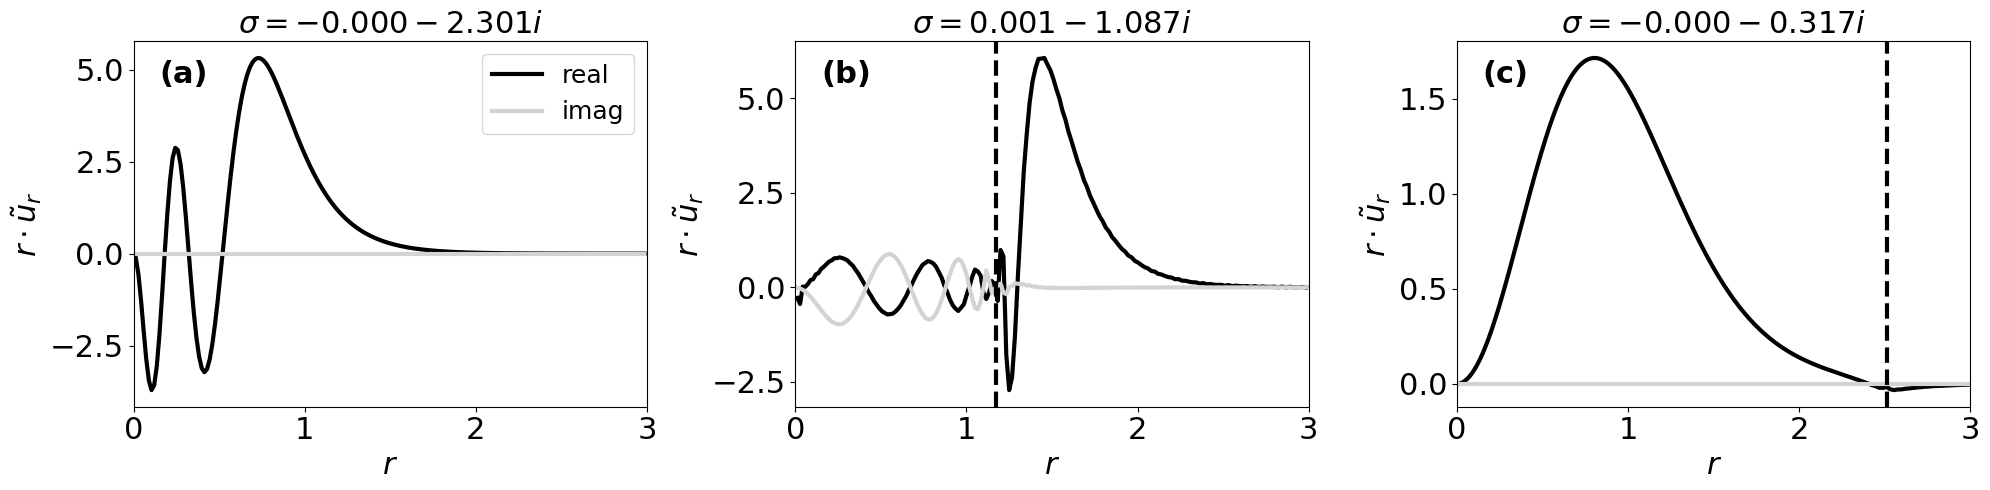

In [26]:
def plot_specific_modes_with_vorticity(data_dir, m, k, indices, r_min=0, r_max=3):
    """
    Plot radial velocity profiles for specific modes and the vorticity profile.
    
    Parameters:
    -----------
    data_dir : str
        Base directory for data files
    m : int
        Azimuthal wavenumber
    k : float
        Axial wavenumber
    indices : list
        List of mode indices to plot
    r_min, r_max : float
        Radial range for plotting
    """
    # Read baseflow to get collocation points
    base_data = read_baseflow(data_dir)
    if base_data is None:
        print("Cannot read baseflow data")
        return
    
    font_size = 22
    r_base = base_data['r']
    uphi_base = base_data['uphi']
    
    # Calculate vorticity for Lamb-Oseen vortex
    # For Lamb-Oseen: Omega(r) = (Gamma/(2*pi*a^2)) * exp(-r^2/a^2)
    # If Omega(0) = 1, then Gamma/(2*pi*a^2) = 1
    # The azimuthal velocity is: u_phi(r) = r * Omega(r)
    # Fit to determine 'a' parameter from the baseflow data
    Omega_base = uphi_base / r_base
    
    # For small r, Omega ≈ Omega_0 * (1 - r^2/a^2), so we can estimate 'a'
    # Find where Omega drops to 1/e of maximum
    Omega_max = Omega_base[0]  # At r->0
    target = Omega_max / np.e
    idx = np.argmin(np.abs(Omega_base - target))
    a_estimate = r_base[idx] if idx > 0 else 1.0
    
    # For Lamb-Oseen vortex: omega_z(r) = (2*Omega_0/a^2) * exp(-r^2/a^2)
    # where Omega_0 = 1 (given)
    vorticity = (2.0 / a_estimate**2) * np.exp(-r_base**2 / a_estimate**2)
    
    # Create figure with 4 subplots (3 for modes + 1 for vorticity)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Get eigenvalue data
    eig_data = None
    for d in all_data:
        if d['m'] == m and abs(d['k'] - k) < 0.01:
            eig_data = d
            break
    
    if eig_data is None:
        print(f"No eigenvalue data found for m={m}, k={k}")
        return
    
    # Plot each mode
    for idx, mode_index in enumerate(indices):
        ax = axes[idx]
        
        # Read velocity profile
        vel_data = read_velocity_profile(data_dir, m, k, mode_index)
        
        if vel_data is None:
            ax.text(0.5, 0.5, f'No data for mode {mode_index}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xlabel('r')
            ax.set_ylabel('r * ur')
            continue
        
        # Get the eigenvalue for this mode
        eigenvalue = None
        for i, eig_idx in enumerate(eig_data['indices']):
            if eig_idx == mode_index:
                eigenvalue = eig_data['eigenvalues'][i]
                break
        
        # Extract data
        r = vel_data['r']
        ur_real = vel_data['ur_real']
        ur_imag = vel_data['ur_imag']
        
        # Filter to specified range
        mask = (r >= r_min) & (r <= r_max)
        r_plot = r[mask]
        
        # Create complex velocity and apply phase shift to make max amplitude purely real
        ur_complex = (ur_real[mask] + 1j * ur_imag[mask]) * r_plot
        
        # Find the phase at maximum amplitude
        amplitudes = np.abs(ur_complex)
        max_idx = np.argmax(amplitudes)
        phase_at_max = np.angle(ur_complex[max_idx])
        
        # Apply phase shift to make the maximum purely real
        ur_complex_shifted = ur_complex * np.exp(-1j * phase_at_max)
        
        # Extract real and imaginary parts after phase shift
        ur_real_plot = np.real(ur_complex_shifted)
        ur_imag_plot = np.imag(ur_complex_shifted)
        
        # Plot real and imaginary parts
        ax.plot(r_plot, ur_real_plot, 'k-', linewidth=3, label='real')
        ax.plot(r_plot, ur_imag_plot, color='lightgray', linestyle='-', linewidth=3, label='imag')
        
        # Add critical layer if it exists
        if eigenvalue is not None:
            omega = eigenvalue.imag
            critical_locs = find_critical_layer_location(data_dir, m, k, omega)
            
            if critical_locs:
                for r_c in critical_locs:
                    if r_min <= r_c <= r_max:
                        ax.axvline(x=r_c, color='black', linestyle='--', linewidth=3, 
                                 label=f'$r_c={r_c:.3f}$')
        
        # Set labels and title
        ax.set_xlabel('$r$', fontsize=font_size)
        ax.set_ylabel('$r \\cdot \\tilde{u}_r$', fontsize=font_size)
        ax.set_xlim(r_min, r_max)
        ax.grid(False)
        if idx == 0:
            ax.legend(fontsize=font_size-4)
        ax.tick_params(labelsize=font_size)
        ax.locator_params(axis='y', nbins=4)
        
        # Add panel label (a, b, c)
        panel_labels = ['(a)', '(b)', '(c)']
        ax.text(0.05, 0.95, panel_labels[idx], transform=ax.transAxes, 
                fontsize=font_size, fontweight='bold', va='top', ha='left')
        
        # Add eigenvalue as title
        if eigenvalue is not None:
            title = f'$\\sigma = {eigenvalue.real:.3f} {eigenvalue.imag:.3f}i$'
        ax.set_title(title, fontsize=font_size)
    
    # # Plot vorticity in the 4th subplot
    # ax_vort = axes[3]
    # mask_vort = (r_base >= r_min) & (r_base <= r_max)
    # r_vort = r_base[mask_vort]
    # vort_plot = vorticity[mask_vort]
    
    # ax_vort.plot(r_vort, vort_plot, 'b-', linewidth=2)
    # ax_vort.set_xlabel('r', fontsize=12)
    # ax_vort.set_ylabel('$\\omega_z$', fontsize=12)
    # ax_vort.set_title(f'Vorticity Profile\n(Lamb-Oseen, $a \\approx {a_estimate:.3f}$)', fontsize=11)
    # ax_vort.set_xlim(r_min, r_max)
    # ax_vort.grid(True, alpha=0.3)
    # ax_vort.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('mode_profiles.pdf', bbox_inches='tight')
    plt.show()

# Plot the specific modes
plot_specific_modes_with_vorticity(
    data_dir=data_dir,
    m=2,
    k=5.0,
    indices = [5, 122, 248], # indices=[5, 183, 353],
    r_min=0,
    r_max=3
)

## Critical Layer Diagnostic Tool

Use this diagnostic function to debug critical layer calculations and verify the locations are correct.

In [ ]:
# Example: Test critical layer calculation for m=2, k=1.0, omega=-1.0
# This should find a critical layer around r ≈ 1.26

m_test = 2
k_test = 1.0
omega_test = -1.0  # Try different values from your eigenvalues

critical_locs = diagnose_critical_layer(data_dir, m_test, k_test, omega_test)

if critical_locs:
    print(f"\n=== Summary ===")
    print(f"Found {len(critical_locs)} critical layer(s) at: {critical_locs}")